# Introducción al análisis frecuencial de señales
## Práctica 5

**Integrantes:**  
- Sara Mejía Zapata  
- María Camila Tobón Úsuga

**Asignatura:** Bioseñales y Sistemas


---

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Ejemplo de la práctica 


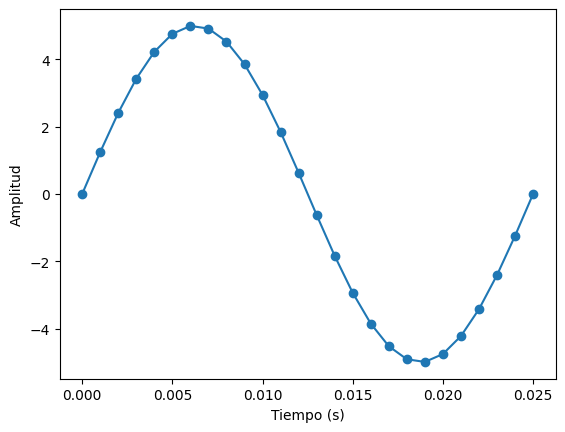

In [13]:
Fo = 40 # Frecuencia fundamental de la señal
Tp = 1/Fo # Periodo de la señal
Fs = 1000 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más una muestra T
A = 5
x = A*np.sin(2*np.pi*Fo*t)
plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()


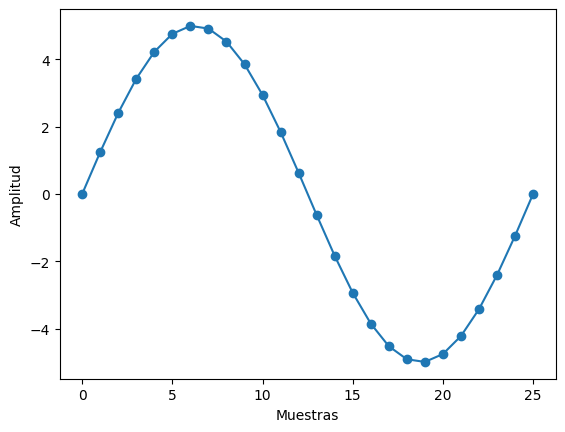

In [14]:
fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.plot(n, x1, marker='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


a)	Compruebe que los valores de las primeras cinco muestras son los mismos

In [15]:
print("Primeras cinco muestras de x:")
print(x[:5])

print("Primeras cinco muestras de x1:")
print(x1[:5])

Primeras cinco muestras de x:
[0.         1.24344944 2.40876837 3.42273553 4.22163963]
Primeras cinco muestras de x1:
[0.         1.24344944 2.40876837 3.42273553 4.22163963]


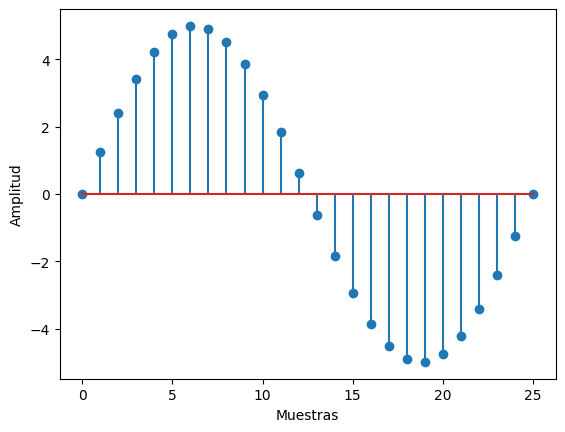

In [16]:

fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.stem(n, x1, markerfmt='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


In [17]:
##energia de la señal en un ciclo
energia = sum(x**2)
print(energia)
#La potencia media de la señal medida en W es en un ciclo:
potencia = energia/(len(t)-1)
print(potencia)
##El valor cuadrático medio es la raíz cuadrada de la potencia:
rms = np.sqrt(potencia)
print(rms)

312.50000000000006
12.500000000000002
3.5355339059327378


In [18]:
#Para hallar la energía, así como la potencia media de la señal considerando 10 ciclos de la sinusoide (250ms):
t10 = np.arange(0,10*Tp+T,T)
x10 = A*np.sin(2*np.pi*Fo*t10)
energia10 = sum(x10**2)
potencia10 = energia10/(len(t10)-1)
rms10 = np.sqrt(potencia10)
print(energia10)
print(potencia10)
print(rms10)


3125.0000000000014
12.500000000000005
3.535533905932738


b) La potencia es la misma que en x(n). ¿Por qué? 

La potencia sale igual porque la potencia media de una señal periódica no depende de cuántos ciclos se tomen, considerando que se deben tomar ciclos completos, en el caso de los 10 ciclos la energia si cambia porque se estan sumando mas muestras, 1 ciclo de energia 3.535 y 10 ciclos 3535 sabiendo que la formula de la potencia es:

$
P = \frac{1}{N}\sum_{n=0}^{N-1} x^2[n]
$

La energia entonces aumento 10 veces pero la duración también 10 veces 

$
P = \frac{3523}{250} = 12.50
$

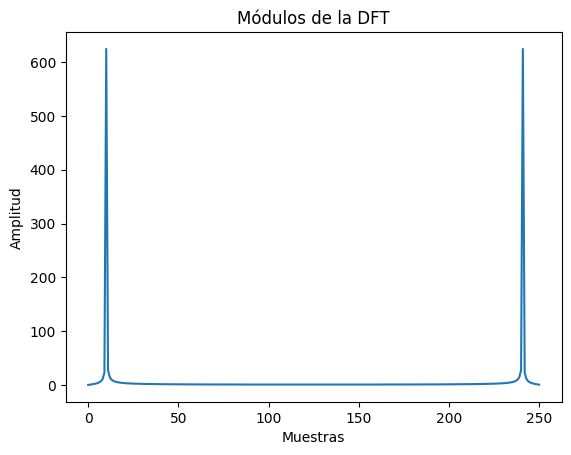

In [19]:
##Análisis de Fourier en tiempo discreto
X10 = np.fft.fft(x10)
plt.plot(abs(X10))
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


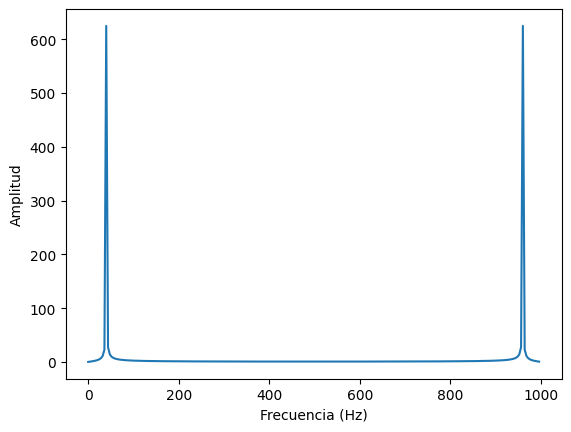

In [20]:
N = len(X10)
F = np.arange(0,N)*Fs/N
plt.plot(F,abs(X10))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.show()


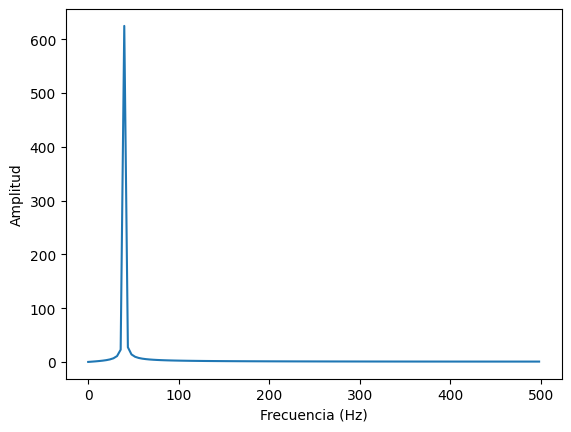

In [21]:
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0,Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.show()


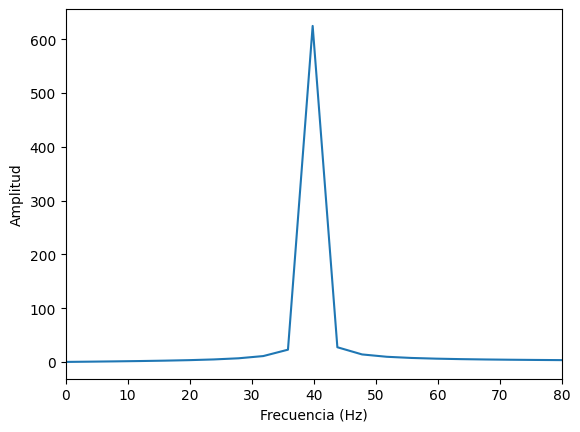

In [22]:
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.xlim(0,80)
plt.show()


**4.1	Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente**

Para la creación de la señal se tendrá en cuenta la señal del ejemplo de la practica, para esto se hará la suma de tres sinusoidades de diferentes frecuencias(40 Hz,80Hz y 160Hz).

Para representar correctamente la señal continua en tiempo discreto es necesario seleccionar una frecuencia de muestreo adecuada.Según el teorema de muestreo de Nyquist, la frecuencia de muestreo debe ser por lo menos el doble de la frecuencia máxima esto se realiza para evitar el fénomeno de aliasing, el cual puede producir una representación incorrecta de las componente frecuenciales.

En nuestro caso la frecuencia máxima de la señal es:

$f_s > 2 f_{max}$

por lo tanto, la frecuencia mínima requerida es: 

$
F_s \geq 2f_{max} = 2(160) = 320 \text{ Hz}
$

Aunque 320 Hz es el mínimo teórico, en la práctica se utilizará una frecuencia mayor para obtener una representación más precisa de la señal y mejorar el análisis espectral. Por esta razón se seleccionó una frecuencia de muestreo de 1000 Hz.

La señal se genera de la siguiente manera: 

$ x(t) = \sin(2\pi \cdot 40t) + \sin(2\pi \cdot 80t) + \sin(2\pi \cdot 160t) $







Frecuencia máxima de la señal : 160 Hz
Fs mínima requerida (Nyquist)  : Fs > 320 Hz
Fs utilizada                   : 1000 Hz


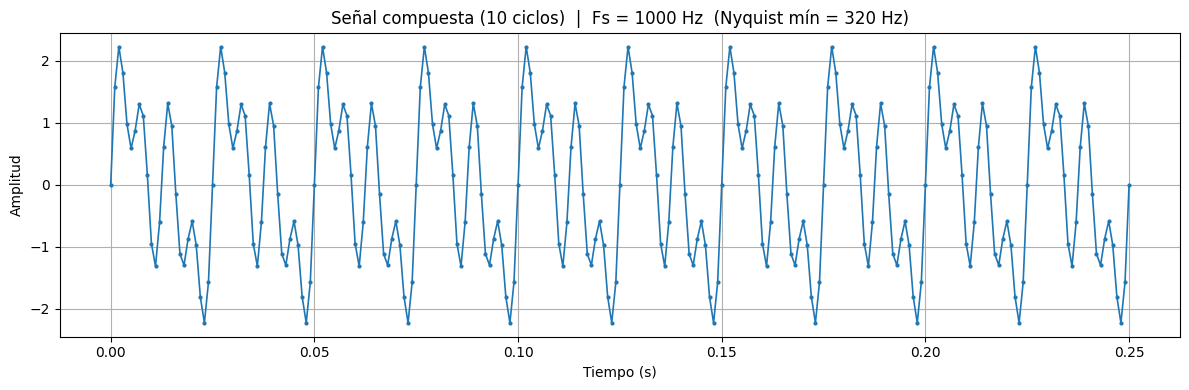

In [ ]:
# Frecuencias de las componentes
f1 = 40
f2 = 80
f3 = 160

# 1. Frecuencia mínima de muestreo (Nyquist)
f_max = f3
Fs_min = 2 * f_max          # = 320 Hz
print(f"Frecuencia máxima de la señal : {f_max} Hz")
print(f"Fs mínima requerida (Nyquist)  : Fs > {Fs_min} Hz")

# 2. Frecuencia de muestreo apropiada
Fs = 1000
T  = 1 / Fs
print(f"Fs utilizada                   : {Fs} Hz")

# 3. Tiempo: 10 ciclos de la componente más lenta (f1 = 40 Hz)
Tp = 10 / f1                # = 0.25 s
t  = np.arange(0, Tp + T, T)

# 4. Señal compuesta
x = (np.sin(2*np.pi*f1*t) +
     np.sin(2*np.pi*f2*t) +
     np.sin(2*np.pi*f3*t))

# 5. Gráfica
plt.figure(figsize=(12, 4))
plt.plot(t, x, marker='o', markersize=2, linewidth=1.2)
plt.title(f"Señal compuesta (10 ciclos)  |  Fs = {Fs} Hz  (Nyquist mín = {Fs_min} Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

**4.2	Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia. Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos de la señal).**

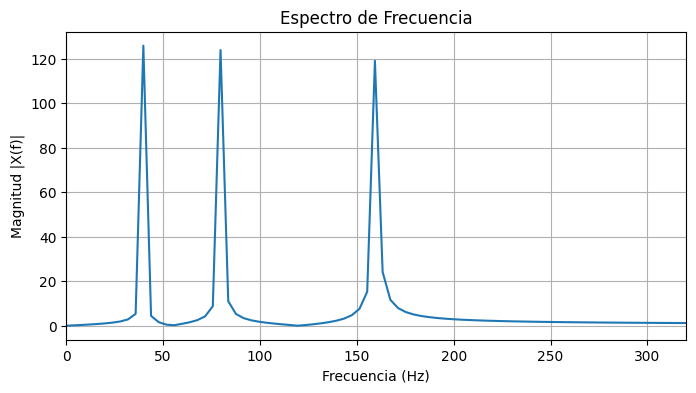

In [25]:
# Transformada de Fourier de la señal
# DFT
X     = np.fft.fft(x)
N     = len(X)
freqs = np.arange(0, N) * Fs / N

# Espectro
plt.figure(figsize=(8,4))
plt.plot(freqs[:N//2], abs(X[:N//2]))
plt.title('Espectro de Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud |X(f)|')
plt.xlim(0, 320)
plt.grid(True)
plt.show()

**4.3	Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior.** 

### Transformadas discretas de Fourier unidimensionales

La FFT $y[k]$ de longitud $N$ de la secuencia $x[n]$ de longitud $N$ se define como:

$$y[k] = \sum_{n=0}^{N-1} e^{-2\pi j \frac{kn}{N}} x[n],$$

y la transformada inversa se define de la siguiente manera[1]:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} e^{2\pi j \frac{kn}{N}} y[k].$$

Para la sintaxis en python usando la libraria Scipy tenemos:

*scipy.fft.ifft* 

*ifft(x, n=None, axis=-1, norm=None, overwrite_x=False, workers=None, *, plan=None)* [2]



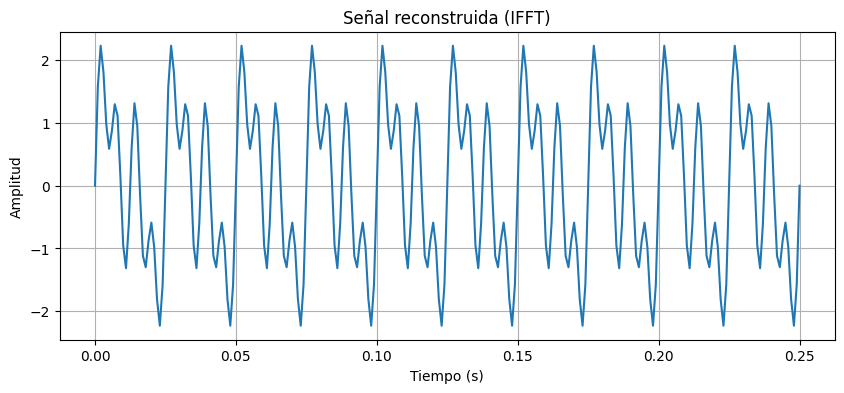

In [28]:
# Transformada Inversa de Fourier
x_reconstruida = np.fft.ifft(X)

# Gráfica
plt.figure(figsize=(10, 4))
plt.plot(t, x_reconstruida.real)
plt.title('Señal reconstruida (IFFT)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

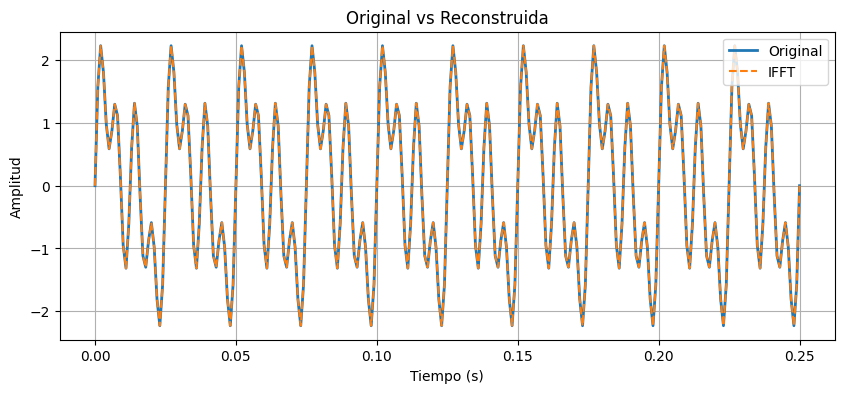

Error máximo: 2.89e-15


In [29]:
# Comparación original vs reconstruida
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Original', linewidth=2)
plt.plot(t, x_reconstruida.real, '--', label='IFFT', linewidth=1.5)
plt.title('Original vs Reconstruida')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

print(f"Error máximo: {np.max(np.abs(x - x_reconstruida.real)):.2e}")

**4.4	¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué?**

C:\Users\sara mejia\AppData\Local\Temp\ipykernel_5256\1119254166.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13]; # esta delimitandose a una banda de frecuencias en especifico de ambas señales


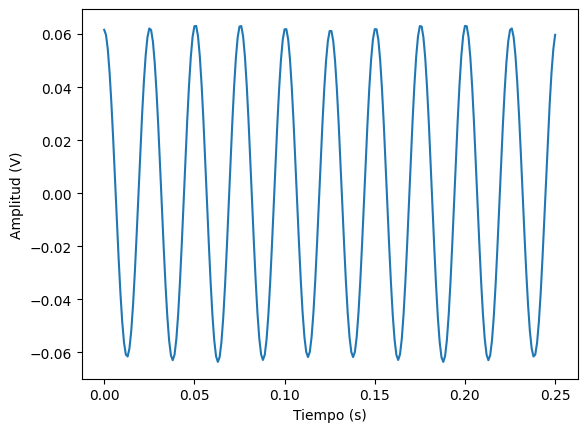

In [34]:
F1 = np.fft.fft(x); #calcula el espectro de la señal (DFT)
F2 = np.zeros((len(F1))); #Crea un espectro vacío con puros ceros
F2[9:13] = F1[9:13]; # esta delimitandose a una banda de frecuencias en especifico de ambas señales
xr = np.fft.ifft(F2); #se le aplica la tranformada inversa de Fourier
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');
plt.show()

Para cada una de las frecuencias tendríamos lo siguiente.

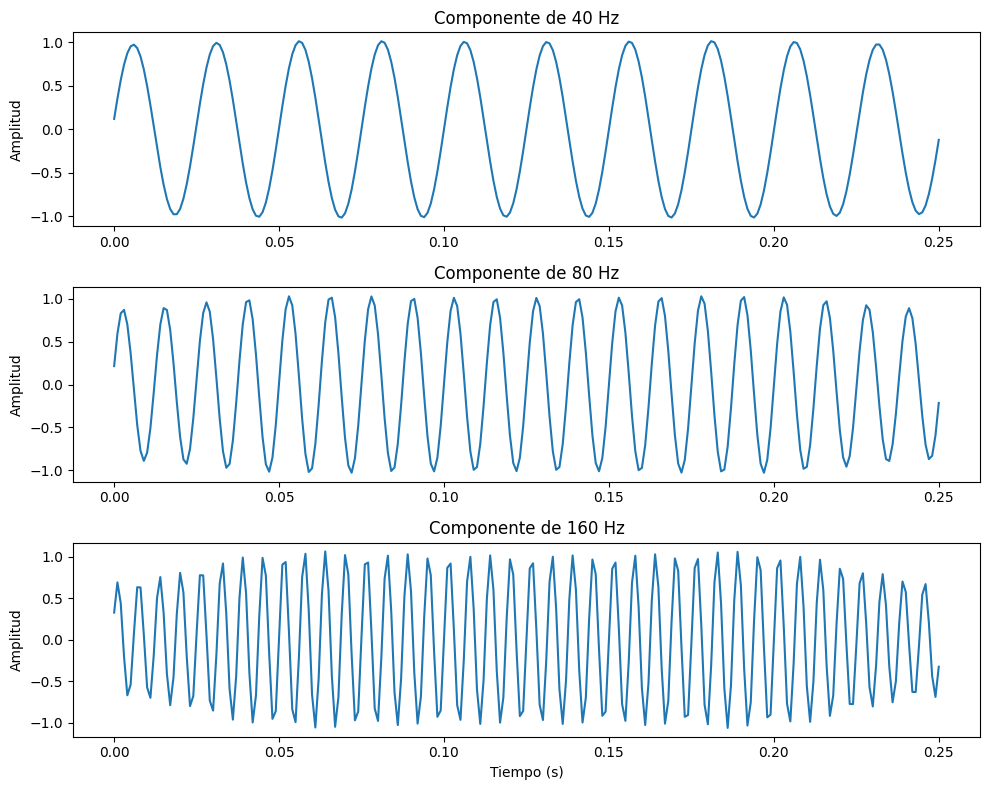

In [35]:

# FFT de la señal
F = np.fft.fft(x)

# Número de muestras
N = len(F)

# Vector tiempo
# (ya definido previamente como t)

#  COMPONENTE 40 Hz 
F40 = np.zeros(N, dtype=complex)

F40[9:13] = F[9:13]
F40[-13:-9] = F[-13:-9]

x40 = np.fft.ifft(F40)

#  COMPONENTE 80 Hz 
F80 = np.zeros(N, dtype=complex)

F80[19:23] = F[19:23]
F80[-23:-19] = F[-23:-19]

x80 = np.fft.ifft(F80)

#  COMPONENTE 160 Hz 
F160 = np.zeros(N, dtype=complex)

F160[39:43] = F[39:43]
F160[-43:-39] = F[-43:-39]

x160 = np.fft.ifft(F160)

# GRÁFICAS 

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, np.real(x40))
plt.title('Componente de 40 Hz')
plt.ylabel('Amplitud')

plt.subplot(3,1,2)
plt.plot(t, np.real(x80))
plt.title('Componente de 80 Hz')
plt.ylabel('Amplitud')

plt.subplot(3,1,3)
plt.plot(t, np.real(x160))
plt.title('Componente de 160 Hz')
plt.ylabel('Amplitud')
plt.xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

Sí, se puede considerar un filtro ya que se seleccionan únicamente ciertas frecuencia de la señal y eliminan las demás mediantes la Trasformada Rápida de Furier(FFT).En este caso la señal solo toma frecuencias comprendidas entre 9:15 y el resto de componentes espectrales se hacen cero.Posteriormente, la señal es recostruida en el dominio del tiempo usando la transformada inversa.

Sin embargo, este procedimiento corresponde más a un filtrado ideal o teótico que a la implementanción de un filtro digital real.Esto se debe a varias razones.Primero, al mudicar una pequeña región del especto sin conservar adecuadamente la simética necesaria en señales, pueden aparecer componentes imaginarias en la señal reconstruida.

Además, el método es causal, ya que requiere conocer toda la señal antes de procesarla, por lo que no puede implementarse en tiempo real.También presenta una transición abrupota entre las frecuencias que se concervan y las que se eliminan, característica de un filtro ideal.Los filtros poseen bandas de transición y se implementan mediante ecuaciones o convolución, como ocurre en filtro digitales digitales como el Butterworth.

Finalmente, este tipo de truncamiento espectral modifica principalmente la magnitud del espectro sin considerar de manera adecuada el efecto sobre la fase, lo que puede generar distorsiones en la forma de onda reconstruida. Por estas razones, aunque sí puede considerarse un proceso de filtrado, se trata de un filtrado idealizado y no de un filtro digital práctico implementado formalmente.

**4.5	El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)**

Claves en el archivo: dict_keys(['__header__', '__version__', '__globals__', 'ECG'])
Muestras: 1250 | Duración: 5.00 s | Fs: 250 Hz


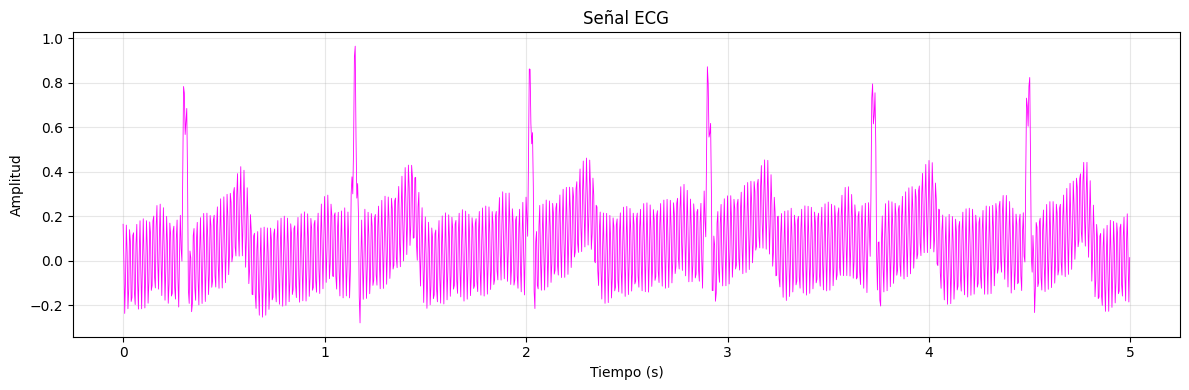

In [50]:

import scipy.io as sio

# Cargar el archivo .mat
mat = sio.loadmat('senecg.mat')

# Ver las claves disponibles en el archivo
print("Claves en el archivo:", mat.keys())

# Cargar la señal 
senal = mat['ECG'].flatten()
fs = 250    # frecuencia de muestreo en Hz
N  = len(senal)
t  = np.arange(N) / fs

print(f"Muestras: {N} | Duración: {N/fs:.2f} s | Fs: {fs} Hz")

# Graficar la señal
plt.figure(figsize=(12, 4))
plt.plot(t, senal, linewidth=0.6, color='magenta')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

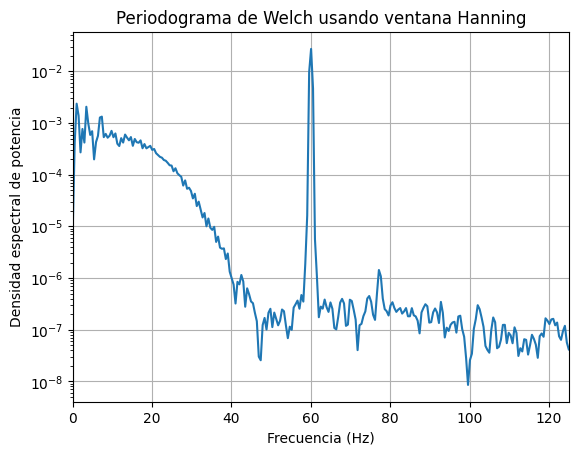

In [ ]:
from scipy.signal import welch as pwelch

# Parámetros Welch
fs = 250
nperseg = 512
noverlap = int(nperseg/2)

# Periodograma de Welch
f, Pxx = pwelch(senal, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# Graficos
plt.figure()
plt.semilogy(f, Pxx)
plt.title('Periodograma de Welch usando ventana Hanning')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.xlim(0, fs/2)  
plt.grid(True)
plt.show()

El filtrado de la señal ECG se justifica a partir del análisis espectral obtenido mediante el periodograma de Welch, ya que en este se evidencian componentes de ruido que no pertenecen a la actividad fisiológica cardíaca y que afectan la calidad de la señal.

En primer lugar, se observa un pico pronunciado y dominante en 60 Hz, con una amplitud considerablemente mayor que el resto del espectro. Esta componente corresponde a la interferencia de la red eléctrica.

Dicho ruido es captado por los electrodos del ECG debido a que estos pueden comportarse como antenas frente a campos electromagnéticos externos. Esta interferencia no tiene origen fisiológico y puede alterar la amplitud y la morfología de las ondas P, QRS y T, dificultando el análisis clínico correcto de la señal. Por esta razón, es necesario aplicar un filtro tipo Notch o rechaza-banda centrado en 60 Hz para eliminar específicamente dicha componente.

Adicionalmente, el periodograma muestra una elevada concentración de energía en frecuencias muy bajas, aproximadamente entre 0 y 5 Hz. Este comportamiento se asocia con la deriva de la línea base (baseline wander), causada principalmente por movimientos del paciente, desplazamientos de los electrodos, cambios en la impedancia de contacto electrodo-piel y el efecto de la respiración. Estas variaciones generan desplazamientos lentos de la señal que no contienen información cardíaca útil. Debido a que la banda de interés clínico del ECG se encuentra aproximadamente entre 0.5 y 40 Hz, las componentes inferiores a 0.5 Hz pueden considerarse ruido y deben ser atenuadas mediante un filtro pasaaltas[3].

Por lo tanto, el filtrado resulta necesario para mejorar la relación señal-ruido del ECG, conservar únicamente la información fisiológicamente relevante y permitir una interpretación más precisa de las características cardíacas presentes en la señal.

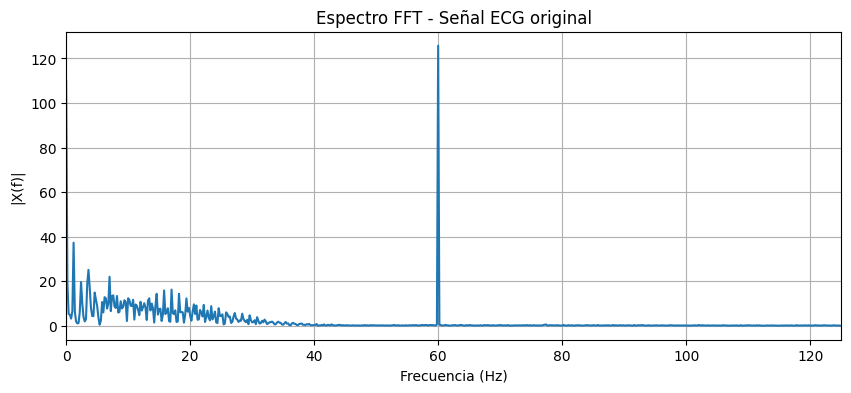

In [ ]:
# FFT de la señal ECG 
F1 = np.fft.fft(senal)
N  = len(senal)
freqs = np.arange(N) * fs / N

# Ver espectro para decidir qué conservar
plt.figure(figsize=(10, 4))
plt.plot(freqs[:N//2], np.abs(F1[:N//2]))
plt.title('Espectro FFT - Señal ECG original')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X(f)|')
plt.xlim(0, 125)
plt.grid(True)
plt.show()

El espectro FFT de la señal ECG original confirma y refuerza lo observado previamente en el periodograma de Welch. La gráfica muestra con total claridad dos regiones problemáticas.La primera es el pico impulsivo en exactamente 60 Hz, con una magnitud de aproximadamente 125, que sobresale de forma abrupta y aislada sobre un espectro que en esa zona tiene valores prácticamente nulos. Esta es la representación en frecuencia de la interferencia de la red eléctrica: una sinusoide pura de 60 Hz superpuesta a la señal fisiológica, cuya naturaleza periódica y determinista produce exactamente ese tipo de pico estrecho y de gran amplitud en la FFT. La segunda región problemática se observa entre 0 y aproximadamente 5 Hz, donde el espectro presenta componentes de amplitud elevada aproximadamente 40 con variaciones irregulares, correspondientes a la deriva de línea base. Fuera de estas dos zonas, el espectro muestra el contenido fisiológico del ECG concentrado entre 1 y 40 Hz con amplitudes que decaen suavemente, lo cual es el comportamiento esperado para una señal cardíaca normal.

Índice f_low  (0.5 Hz):  2
Índice f_high (40 Hz): 200


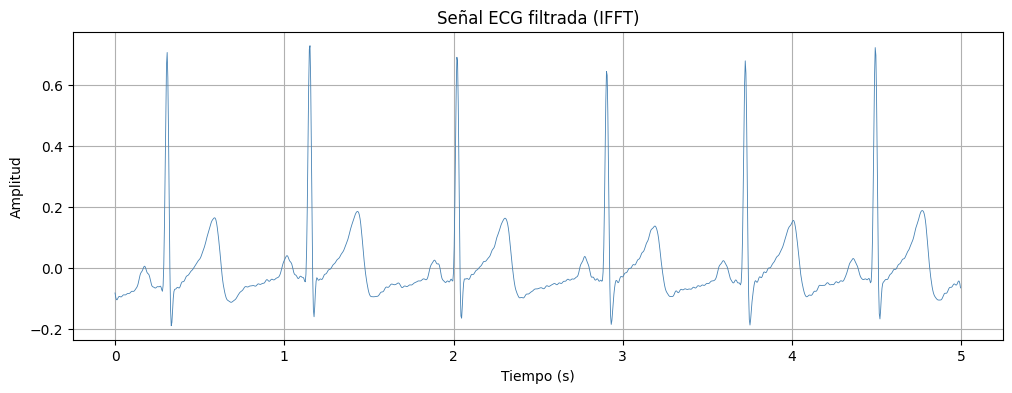

In [ ]:
# 2. Filtro: conservar solo frecuencias de interés (0.5 – 40 Hz)
# El ECG  tiene energía útil entre 0.5 y 40 Hz
# Ruido de alta frecuencia (>40 Hz) y DC (<0.5 Hz) se eliminan

f_low  = 0.5   # Hz - eliminar componente DC y deriva
f_high = 40    # Hz - eliminar ruido de alta frecuencia

idx_low  = round(f_low  * N / fs)
idx_high = round(f_high * N / fs)

print(f"Índice f_low  ({f_low} Hz):  {idx_low}")
print(f"Índice f_high ({f_high} Hz): {idx_high}")

# Filtro pasa-banda 
F2 = np.zeros(len(F1), dtype=complex)
F2[idx_low:idx_high+1]           = F1[idx_low:idx_high+1]           # frecuencias positivas
F2[N-idx_high:N-idx_low+1]       = F1[N-idx_high:N-idx_low+1]       # frecuencias negativas (simétricas)

# ── 3. Transformada inversa ────────────────────────────────────────────────
xr = np.fft.ifft(F2)

fig = plt.figure(figsize=(12, 4))
ax  = fig.add_subplot(111)
ax.plot(t, np.real(xr), linewidth=0.6, color='steelblue')
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud')
plt.title('Señal ECG filtrada (IFFT)')
plt.grid(True)
plt.show()

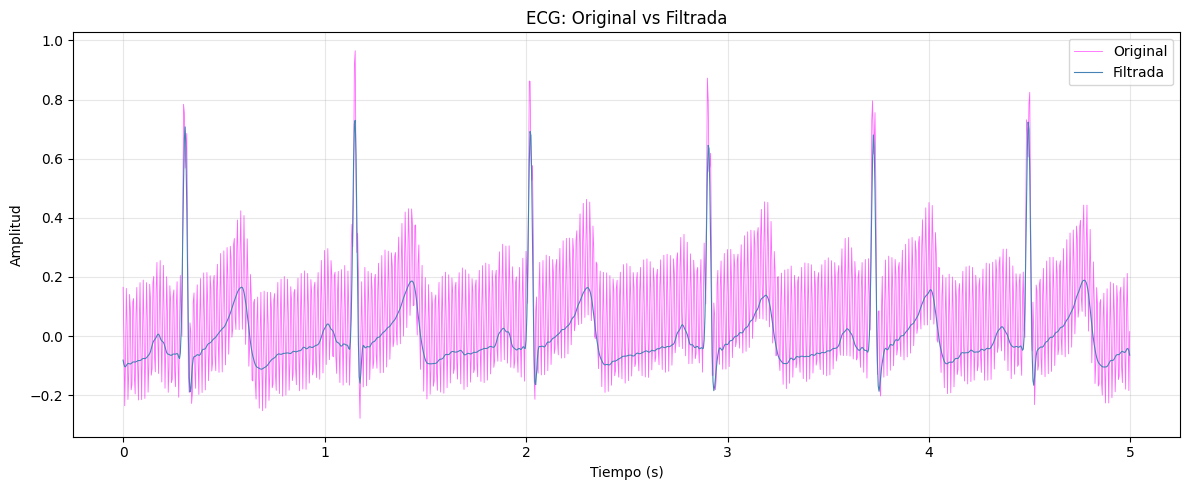

In [79]:
# ── 4. Comparación original vs filtrada ────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(t, senal,        linewidth=0.6, alpha=0.6, label='Original',  color='magenta')
plt.plot(t, np.real(xr), linewidth=0.8, label='Filtrada', color='steelblue')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('ECG: Original vs Filtrada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La comparación entre la señal original y la filtrada muestra claramente que el filtrado funcionó bien. En la señal magenta se ve esa vibración rápida y densa que recubre toda la forma de onda, que es exactamente cómo se ve una sinusoide de 60 Hz en el tiempo.

Por otro lado, En la señal azul se va la vibración de 60 Hz y la línea base se estabiliza, pero lo más importante es que la forma del ECG queda intacta, los picos R siguen ahí, las ondas P y T son visibles entre latidos y los intervalos entre complejos no se distorsionaron. Eso indica que los filtros actuaron justo donde debían sin tocar la señal fisiológica.



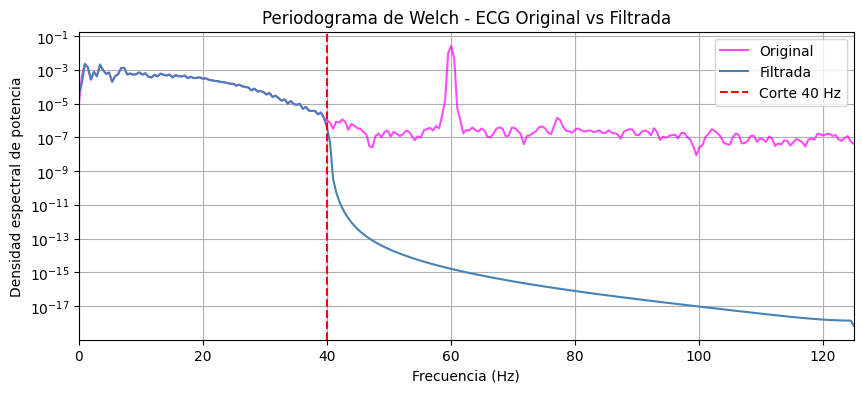

In [85]:
# ── 5. Comprobación con Periodograma de Welch (original vs filtrada) ────────
f_w, Pxx_orig     = pwelch(senal,          fs=fs, window='hann', nperseg=512, noverlap=256)
f_w, Pxx_filtrada = pwelch(np.real(xr),   fs=fs, window='hann', nperseg=512, noverlap=256)

plt.figure(figsize=(10, 4))
plt.semilogy(f_w, Pxx_orig,     color='magenta',   alpha=0.7, label='Original')
plt.semilogy(f_w, Pxx_filtrada, color='steelblue',            label='Filtrada')
plt.axvline(f_high, color='red', linestyle='--', label=f'Corte {f_high} Hz')
plt.title('Periodograma de Welch - ECG Original vs Filtrada')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.xlim(0, 125)
plt.legend()
plt.grid(True)
plt.show()

El periodograma comparativo confirma en frecuencia lo que ya vimos en el tiempo. La señal original mantiene el pico en 60 Hz y toda la energía por encima de 40 Hz que se habia identificado como ruido. La señal filtrada cae de forma pronunciada a partir de la línea de corte en 40 Hz, bajando desde niveles de 10⁻⁵ hasta 10⁻¹⁷ al final del espectro, lo que indica que el filtro eliminó prácticamente toda la energía fuera de la banda fisiológica. El pico de 60 Hz desaparece por completo en la señal filtrada, que es la prueba más directa de que el "filtro" correctamente. Por debajo de 40 Hz ambas curvas coinciden casi perfectamente, lo cual es la validación más importante de que el filtrado no alteró el contenido fisiológico de la señal y solo actuó sobre las frecuencias de ruido.

**4.6	Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)**

In [81]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# Cargar señal control
mat_control = sio.loadmat('C012_EP_reposo_CONTROL')
print("Claves CONTROL:", mat_control.keys())

# Cargar señal Parkinson
mat_parkinson = sio.loadmat('P004_EP_reposo_PARKISON')
print("Claves PARKINSON:", mat_parkinson.keys())

Claves CONTROL: dict_keys(['__header__', '__version__', '__globals__', 'data'])
Claves PARKINSON: dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [82]:
# Extraer datos
data_control   = mat_control['data']
data_parkinson = mat_parkinson['data']

print("Shape CONTROL:   ", data_control.shape)
print("Shape PARKINSON: ", data_parkinson.shape)

Shape CONTROL:    (8, 2000, 172)
Shape PARKINSON:  (8, 2000, 138)


Canales disponibles: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4']
Canal seleccionado: C3
Duración CONTROL:   1376.00 s
Duración PARKINSON: 1104.00 s


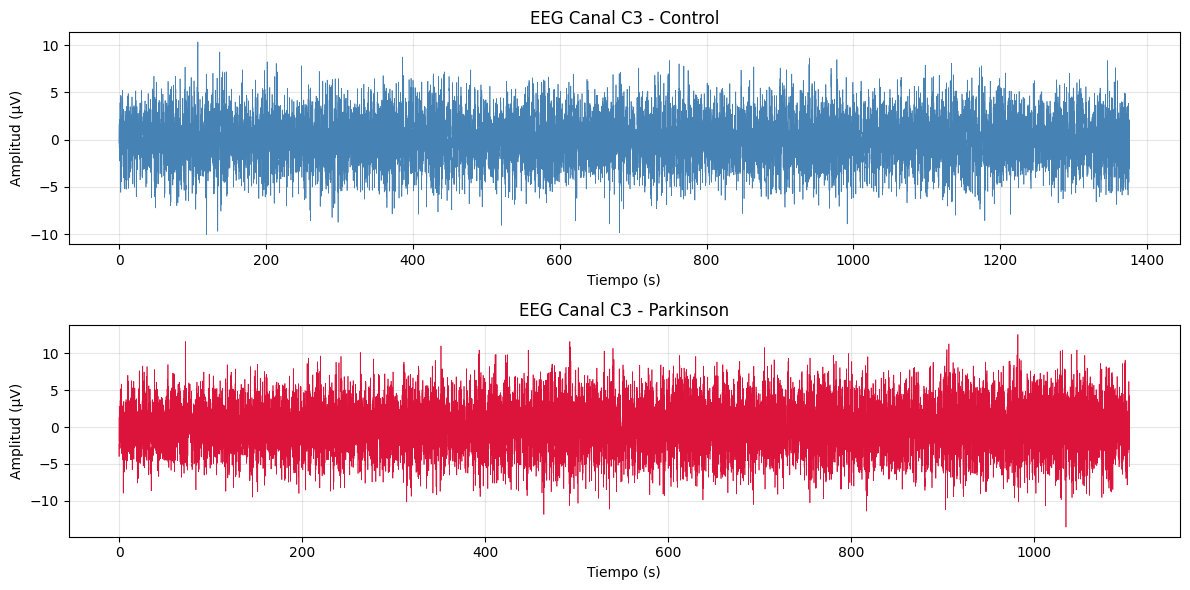

In [83]:
# 8 canales, 2000 muestras por época, 172/138 épocas
# Frecuencia de muestreo EEG típica
fs = 250  # Hz

# Canales disponibles (estándar 10-20 para 8 canales)
canales = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4']
print("Canales disponibles:", canales)

# Elegir canal (ej: C3 = índice 4, relacionado con actividad motora → relevante en Parkinson)
canal_idx = 4  # C3

# Concatenar todas las épocas en una señal continua
senal_control   = data_control[canal_idx, :, :].flatten(order='F')
senal_parkinson = data_parkinson[canal_idx, :, :].flatten(order='F')

# Tiempo
t_control   = np.arange(len(senal_control))   / fs
t_parkinson = np.arange(len(senal_parkinson)) / fs

print(f"Canal seleccionado: {canales[canal_idx]}")
print(f"Duración CONTROL:   {t_control[-1]:.2f} s")
print(f"Duración PARKINSON: {t_parkinson[-1]:.2f} s")

# Graficar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(t_control, senal_control, linewidth=0.5, color='steelblue')
ax1.set_title(f'EEG Canal {canales[canal_idx]} - Control')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud (µV)')
ax1.grid(True, alpha=0.3)

ax2.plot(t_parkinson, senal_parkinson, linewidth=0.5, color='crimson')
ax2.set_title(f'EEG Canal {canales[canal_idx]} - Parkinson')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud (µV)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

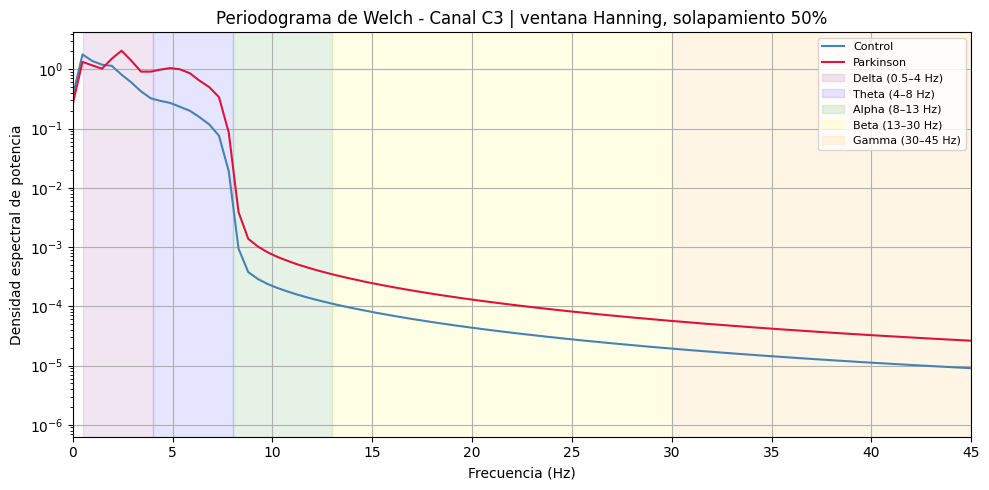

In [84]:
from scipy.signal import welch as pwelch

# Parámetros Welch
nperseg  = 512          # ventana de 512 muestras → resolución = 250/512 ≈ 0.49 Hz
noverlap = int(nperseg * 0.5)  # 50% solapamiento

# Periodograma de Welch para ambas señales
f_c, Pxx_c = pwelch(senal_control,   fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
f_p, Pxx_p = pwelch(senal_parkinson, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# Gráfica comparativa
plt.figure(figsize=(10, 5))
plt.semilogy(f_c, Pxx_c, color='steelblue', label='Control')
plt.semilogy(f_p, Pxx_p, color='crimson',   label='Parkinson')

# Bandas EEG
plt.axvspan(0.5,  4,  alpha=0.1, color='purple', label='Delta (0.5–4 Hz)')
plt.axvspan(4,    8,  alpha=0.1, color='blue',   label='Theta (4–8 Hz)')
plt.axvspan(8,    13, alpha=0.1, color='green',  label='Alpha (8–13 Hz)')
plt.axvspan(13,   30, alpha=0.1, color='yellow', label='Beta (13–30 Hz)')
plt.axvspan(30,   45, alpha=0.1, color='orange', label='Gamma (30–45 Hz)')

plt.title(f'Periodograma de Welch - Canal C3 | ventana Hanning, solapamiento 50%')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.xlim(0, 45)
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

## Referencias

[1] https://docs.scipy.org/doc/scipy/tutorial/fft.html

[2]https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.ifft.html

[3] https://www.jscholaronline.org/full-text/JBER/3_101/Signal-Processing.php 